# **1. PARAMETERS INITIALIZATION**

In [6]:
import json

def ask_int(prompt, default):
    while True:
        raw = input(f"{prompt} (default {default}): ").strip()
        if raw == "":
            return int(default)
        try:
            return int(float(raw))


        except ValueError:
            print("Please enter a valid integer.")

def ask_float(prompt, default):
    while True:
        raw = input(f"{prompt} (default {default}): ").strip()
        if raw == "":
            return float(default)
        try:
            return float(raw)
        except ValueError:
            print("Please enter a valid number.")

def ask_currency(prompt, default):
    val = ask_float(prompt, default)
    if float(val).is_integer():
        return int(val)
    return val

# ------------------------
# DEFAULT CONFIGURATIONS
# ------------------------
DEFAULTS = {
    "WEEKS": 104,
    "LEAD_TIME": 2,
    "OUL_FACTOR": 3,
    "INITIAL_INVENTORY": 80,
    # Demand distribution default params (normal)
    "DEMAND_PARAMS": {"mean": 25.0, "std": 5.0},

    "PRICING": {
        "retailer": {"sell": 170, "buy": 130},
        "distributor": {"sell": 130, "buy": 100},
        "manufacturer": {"sell": 100, "buy": 60}
    },

    "CREDIT_TERMS": {
        "retailer": {"pay_supplier": 2, "receive_customer": 0},
        "distributor": {"pay_supplier": 2, "receive_customer": 2},
        "manufacturer": {"pay_supplier": 0, "receive_customer": 2}
    },

    "INITIAL_CASH": {
        "retailer": 10000,
        "distributor": 30000,
        "manufacturer": 50000
    },

    "HOLDING_COST": {
        "retailer": 15,
        "distributor": 10,
        "manufacturer": 5
    },

    "SHORTAGE_COST": {
        "retailer": 40,
        "distributor": 30,
        "manufacturer": 40
    }
}

# ------------------------
# Ask user whether to use defaults or change
# ------------------------
print("Do you want to Continue with the Default Parameters or Change?")

while True:
    choice = input("Enter 'y' for Default Parameters OR 'n' to Change: ").strip().lower()
    if choice == "":
        choice = "y"
    if choice in ("y", "n"):
        break
    print("Please enter either 'y' or 'n'.")

# ------------------------
# Build configuration
# ------------------------
if choice == "y":
    config = json.loads(json.dumps(DEFAULTS))
else:
    config = {}
    print("\nYou chose to change parameters.\n")
    config["WEEKS"] = ask_int("Number of weeks", DEFAULTS["WEEKS"])
    #config["LEAD_TIME"] = ask_int("Lead Time (weeks)", DEFAULTS["LEAD_TIME"])
    #config["OUL_FACTOR"] = ask_int("OUL Factor", DEFAULTS["OUL_FACTOR"])
    config["INITIAL_INVENTORY"] = ask_int("Initial Inventory", DEFAULTS["INITIAL_INVENTORY"])

    # Demand: ALWAYS ask mean and std (no choice asked here)
    print("\nDemand distribution will be Normal. Enter distribution parameters:")
    mean_val = ask_float("  Mean (average demand)", DEFAULTS["DEMAND_PARAMS"]["mean"])
    std_val = ask_float("  Standard deviation (std)", DEFAULTS["DEMAND_PARAMS"]["std"])
    if std_val < 0:
        print("  Note: std cannot be negative. Using absolute value.")
        std_val = abs(std_val)
    config["DEMAND_PARAMS"] = {"mean": float(mean_val), "std": float(std_val)}

    # Pricing
    pricing = {}
    for role, vals in DEFAULTS["PRICING"].items():
        print(f"\n--- {role.capitalize()} Pricing ---")
        sell = ask_currency("  Selling Price", vals["sell"])
        buy = ask_currency("  Purchase/Production Cost", vals["buy"])
        pricing[role] = {"sell": sell, "buy": buy}
    config["PRICING"] = pricing

    # Credit terms
    credit = {}
    for role, vals in DEFAULTS["CREDIT_TERMS"].items():
        print(f"\n--- {role.capitalize()} Credit Terms ---")
        pay = ask_int("  Weeks to Pay Supplier", vals["pay_supplier"])
        rec = ask_int("  Weeks to Receive Payment from Customer", vals["receive_customer"])
        credit[role] = {"pay_supplier": pay, "receive_customer": rec}
    config["CREDIT_TERMS"] = credit

    # Initial Cash
    cash = {}
    for role, val in DEFAULTS["INITIAL_CASH"].items():
        cash[role] = ask_currency(f"  Initial Cash ({role.capitalize()})", val)
    config["INITIAL_CASH"] = cash

    # Holding cost
    hold = {}
    for role, val in DEFAULTS["HOLDING_COST"].items():
        hold[role] = ask_currency(f"  Holding Cost ({role.capitalize()})", val)
    config["HOLDING_COST"] = hold

    # Shortage cost
    short = {}
    for role, val in DEFAULTS["SHORTAGE_COST"].items():
        short[role] = ask_currency(f"  Shortage Cost ({role.capitalize()})", val)
    config["SHORTAGE_COST"] = short

# ensure all keys exist
for k in ("WEEKS","LEAD_TIME","INITIAL_INVENTORY","OUL_FACTOR","DEMAND_PARAMS",
          "PRICING","CREDIT_TERMS","INITIAL_CASH","HOLDING_COST","SHORTAGE_COST"):
    if k not in config:
        config[k] = DEFAULTS[k]

# ------------------------
# Print Clean parameter table
# ------------------------
def print_table(title, rows):
    print("\n" + title)
    print("-" * len(title))
    col1 = max(len(r[0]) for r in rows) + 2
    col2 = max(len(str(r[1])) for r in rows) + 2
    for key, val in rows:
        print(f"{key.ljust(col1)}{str(val).rjust(col2)}")
    print()

# display demand as NORM.INV(RAND(),mean,std)
mean = config["DEMAND_PARAMS"]["mean"]
std = config["DEMAND_PARAMS"]["std"]
demand_expr = f"NORM.INV(RAND(),{mean},{std})"

print_table("MAIN PARAMETERS", [
    ("Number of weeks", f"1 to {config['WEEKS']}"),
    ("Lead Time", config["LEAD_TIME"]),
    ("OUL Factor", config["OUL_FACTOR"]),
    ("Initial Inventory", config["INITIAL_INVENTORY"]),
    ("Demand Distribution", demand_expr)
])

print_table("PRICING", [
    ("Retailer Selling Price", config["PRICING"]["retailer"]["sell"]),

    ("Manufacturer Production Cost", config["PRICING"]["manufacturer"]["buy"])
])

# print_table("CREDIT TERMS", [
#     ("Credit [Customer → Retailer]", config["CREDIT_TERMS"]["retailer"]["receive_customer"]),
#     ("Credit [Retailer → Distributor]", config["CREDIT_TERMS"]["retailer"]["pay_supplier"]),
#     ("Credit [Distributor → Manufacturer]", config["CREDIT_TERMS"]["distributor"]["pay_supplier"])
# ])

print_table("INITIAL CASH", [
    ("Initial Cash [Retailer]", config["INITIAL_CASH"]["retailer"]),
    ("Initial Cash [Distributor]", config["INITIAL_CASH"]["distributor"]),
    ("Initial Cash [Manufacturer]", config["INITIAL_CASH"]["manufacturer"])
])

print_table("HOLDING COST PER WEEK PER UNIT", [
    ("Retailer", config["HOLDING_COST"]["retailer"]),
    ("Distributor", config["HOLDING_COST"]["distributor"]),
    ("Manufacturer", config["HOLDING_COST"]["manufacturer"])
])

print_table("SHORTAGE COST PER WEEK PER UNIT", [
    ("Retailer", config["SHORTAGE_COST"]["retailer"]),
    ("Distributor", config["SHORTAGE_COST"]["distributor"]),
    ("Manufacturer", config["SHORTAGE_COST"]["manufacturer"])
])

# ------------------------
# Save config to JSON for Block B

with open("config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)
print("Saved configuration to config.json\n")

Do you want to Continue with the Default Parameters or Change?
Enter 'y' for Default Parameters OR 'n' to Change: y

MAIN PARAMETERS
---------------
Number of weeks                         1 to 104
Lead Time                                      2
OUL Factor                                     3
Initial Inventory                             80
Demand Distribution    NORM.INV(RAND(),25.0,5.0)


PRICING
-------
Retailer Selling Price          170
Manufacturer Production Cost     60


INITIAL CASH
------------
Initial Cash [Retailer]        10000
Initial Cash [Distributor]     30000
Initial Cash [Manufacturer]    50000


HOLDING COST PER WEEK PER UNIT
------------------------------
Retailer        15
Distributor     10
Manufacturer     5


SHORTAGE COST PER WEEK PER UNIT
-------------------------------
Retailer        40
Distributor     30
Manufacturer    40

Saved configuration to config.json



# **2. DEMAND INITIALIZATION**

In [7]:
import json
import numpy as np
import sys

# Load configuration (from Block A)
with open("config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# Excel (fixed) demand data for 104 weeks (same as your earlier array)
DEFAULT_CUSTOMER_DEMAND = np.array([
    25,24,15,21,26,24,26,9,18,22,23,24,20,24,20,19,17,17,14,27,
    20,12,21,13,24,26,14,18,25,27,20,12,16,23,13,17,15,14,22,22,
    19,10,22,17,31,10,27,27,16,17,16,16,22,24,15,19,14,23,19,19,
    31,13,21,17,20,23,24,17,17,19,21,29,16,23,20,23,24,22,16,23,
    14,20,19,27,26,14,13,32,23,31,24,29,24,22,19,19,25,21,26,15,
    17,32,22,24
], dtype=float)

# ------------------------
# Demand selection
# ------------------------
print("\nDemand Selection")
print("You can choose to use the Default Excel demand (useful for comparisons) or generate randomized demand.")


while True:
    choice = input("Enter 'd' for Default Excel demand OR 'r' for Random Normal demand: ").strip().lower()
    if choice == "":
        choice = "d"
    if choice in ("d", "r"):
        break
    print("Please enter 'd' or 'r'.")

# ------------------------
# Produce CUSTOMER_DEMAND_DATA
# ------------------------
if choice == "d":
    CUSTOMER_DEMAND_DATA = DEFAULT_CUSTOMER_DEMAND.copy().astype(int)
    print("\nUsing Default Excel demand =", CUSTOMER_DEMAND_DATA)

else:
    # Use mean & std and weeks from config saved by Block A — no hard-coded defaults here
    try:
        weeks = int(config["WEEKS"])
    except KeyError:
        raise KeyError("WEEKS not found in config.json. Run Block A first to create config.json with WEEKS.")

    try:
        demand_params = config["DEMAND_PARAMS"]
        mean = float(demand_params["mean"])
        std = float(demand_params["std"])
    except KeyError:
        raise KeyError("DEMAND_PARAMS (mean/std) not found in config.json. Run Block A first to set DEMAND_PARAMS.")

    # reproducible seed; change/remove if you want different draws each run
    np.random.seed(42)
    vals = np.random.normal(loc=mean, scale=std, size=weeks)
    CUSTOMER_DEMAND_DATA = np.maximum(0, np.round(vals)).astype(int)

    print(f"\nGenerated Random Normal demand the below values")
    print(f"  mean = {mean}, std = {std}, weeks = {weeks}")
    print("Sample (first 10):", CUSTOMER_DEMAND_DATA[:10])

# ------------------------
# CUSTOMER_DEMAND_DATA ready
# ------------------------
print("\nReady for simulation....")
# Optional: save to csv
# np.savetxt("customer_demand.csv", CUSTOMER_DEMAND_DATA, delimiter=",", fmt="%d")



Demand Selection
You can choose to use the Default Excel demand (useful for comparisons) or generate randomized demand.
Enter 'd' for Default Excel demand OR 'r' for Random Normal demand: 

Using Default Excel demand = [25 24 15 21 26 24 26  9 18 22 23 24 20 24 20 19 17 17 14 27 20 12 21 13
 24 26 14 18 25 27 20 12 16 23 13 17 15 14 22 22 19 10 22 17 31 10 27 27
 16 17 16 16 22 24 15 19 14 23 19 19 31 13 21 17 20 23 24 17 17 19 21 29
 16 23 20 23 24 22 16 23 14 20 19 27 26 14 13 32 23 31 24 29 24 22 19 19
 25 21 26 15 17 32 22 24]

Ready for simulation....


# **3. RUN THE SIMULATION**

In [9]:
import math
import pandas as pd

def run_simulation(config, customer_demand):

    # -------------------------------
    # 1. Setup Parameters
    # -------------------------------
    WEEKS = config["WEEKS"]
    INITIAL_INVENTORY = config["INITIAL_INVENTORY"]
    OUL_FACTOR = config["OUL_FACTOR"]
    LEAD_TIME = config["LEAD_TIME"]

    PRICING_SIM = {}
    for role in ["retailer", "distributor", "manufacturer"]:
        PRICING_SIM[role] = {
            "sell": config["PRICING"][role]["sell"],
            "buy": config["PRICING"][role]["buy"],
            "holding": config["HOLDING_COST"][role],
            "shortage": config["SHORTAGE_COST"][role],
            "initial_cash": config["INITIAL_CASH"][role]
        }

    CREDIT_TERMS = config["CREDIT_TERMS"]

    # Column names
    COLS = {
        "retailer": {
            "demand": "CUSTOMER DEMAND", "order": "ORDER PLACED TO DISTRIBUTOR",
            "invoice": "INVOICE TO CUSTOMER", "purchase": "PURCHASE COST"
        },
        "distributor": {
            "demand": "ORDERS FROM RETAILER", "order": "ORDER PLACED TO MANUFACTURER",
            "invoice": "INVOICE TO RETAILER", "purchase": "PURCHASE COST"
        },
        "manufacturer": {
            "demand": "ORDERS FROM DISTRIBUTOR", "order": "ORDER PLACED FOR PRODUCTION",
            "invoice": "INVOICE TO DISTRIBUTOR", "purchase": "PRODUCTION COST"
        }
    }

    def excel_round_up(n):
        return math.ceil(n)

    # -------------------------------
    # 2. Initialization
    # -------------------------------

    history_R, history_D, history_M = [], [], []

    state = {
        "retailer": {"inv": INITIAL_INVENTORY, "cash": PRICING_SIM["retailer"]["initial_cash"]},
        "distributor": {"inv": INITIAL_INVENTORY, "cash": PRICING_SIM["distributor"]["initial_cash"]},
        "manufacturer": {"inv": INITIAL_INVENTORY, "cash": PRICING_SIM["manufacturer"]["initial_cash"]}
    }

    transit = {
        "R_incoming_goods": {}, "D_incoming_goods": {}, "M_incoming_goods": {},
        "D_incoming_demand": {}, "M_incoming_demand": {}
    }

    # -------------------------------
    # 3. Main Simulation Loop
    # -------------------------------
    for t in range(WEEKS):
        week = t + 1

        # -----------------------------
        # Incoming
        # -----------------------------
        r_goods_rec = transit["R_incoming_goods"].get(week, 0)
        d_goods_rec = transit["D_incoming_goods"].get(week, 0)
        m_goods_rec = transit["M_incoming_goods"].get(week, 0)

        r_demand = customer_demand[t] if t < len(customer_demand) else 0
        d_demand = transit["D_incoming_demand"].get(week, 0)
        m_demand = transit["M_incoming_demand"].get(week, 0)

        # -----------------------------
        # Forecast + OUL + Orders
        # -----------------------------
        def plan(entity, demand, hist, goods_rec):
            cols = COLS[entity]

            if week == 1:
                fc = 20
            elif week == 2:
                fc = hist[0][cols["demand"]]
            else:
                d1 = hist[t-1][cols["demand"]]
                d2 = hist[t-2][cols["demand"]]
                fc = excel_round_up((d1 + d2) / 2)

            oul = OUL_FACTOR * fc
            beg_inv = state[entity]["inv"] + goods_rec

            if t == 0:
                prev_order = 0
            else:
                prev_order = hist[t-1][cols["order"]]

            inv_pos = beg_inv + prev_order
            order = max(0, oul - inv_pos)
            return fc, oul, beg_inv, inv_pos, order

        r_fc, r_oul, r_beg, r_ip, r_order = plan("retailer", r_demand, history_R, r_goods_rec)
        d_fc, d_oul, d_beg, d_ip, d_order = plan("distributor", d_demand, history_D, d_goods_rec)
        m_fc, m_oul, m_beg, m_ip, m_order = plan("manufacturer", m_demand, history_M, m_goods_rec)

        # -----------------------------
        # Fulfillment
        # -----------------------------
        def fulfill(beg, demand):
            sold = min(beg, demand)
            lost = max(0, demand - beg)
            end = beg - sold
            return beg, sold, lost, end

        r_avail, r_sold, r_lost, r_end = fulfill(r_beg, r_demand)
        d_avail, d_sold, d_lost, d_end = fulfill(d_beg, d_demand)
        m_avail, m_sold, m_lost, m_end = fulfill(m_beg, m_demand)

        state["retailer"]["inv"] = r_end
        state["distributor"]["inv"] = d_end
        state["manufacturer"]["inv"] = m_end

        # -----------------------------
        # Delay Scheduling
        # -----------------------------
        transit["D_incoming_demand"][week+1] = r_order
        transit["M_incoming_demand"][week+1] = d_order

        transit["R_incoming_goods"][week+1] = d_sold
        transit["D_incoming_goods"][week+1] = m_sold

        transit["M_incoming_goods"][week+LEAD_TIME] = m_order


        # -----------------------------
        # Financials (MODIFIED)
        # -----------------------------
        def finance(role, sold, goods_rec, end_inv, lost_sales, hist, produced=0):
            p = PRICING_SIM[role]

            # Retailer revenue (only retailer generates external revenue)
            if role == "retailer":
                total_revenue = sold * p["sell"]

                # STORE TOTAL REVENUE (GLOBAL)

                state["total_revenue"] = total_revenue

            else:
                total_revenue = 0

            # Retrieve shared revenue
            total_revenue = state.get("total_revenue", 0)

            # Revenue sharing ratios
            r_ratio = 0.234
            d_ratio = 0.238
            m_ratio = 0.528

            # -----------------------------
            # REVENUE SHARING
            # -----------------------------
            if total_revenue > 0:
                if role == "retailer":
                    inflow = total_revenue * r_ratio
                elif role == "distributor":
                    inflow = total_revenue * d_ratio
                else:  # manufacturer
                    inflow = total_revenue * m_ratio
            else:
                inflow = 0

            # -----------------------------
            # PRODUCTION COST
            # -----------------------------
            if role == "manufacturer":
                production_cost = produced * p["buy"]
            else:
                production_cost = 0

            # No internal purchase payments
            outflow = 0

            # Holding & shortage costs remain
            hold = end_inv * p["holding"]
            short = lost_sales * p["shortage"]
            # -----------------------------
            # OVERHEAD EXPENSES (NEW)
            # -----------------------------
            if role == "retailer":
                overhead_rate = 10
            elif role == "distributor":
                overhead_rate = 7
            else:
                overhead_rate = 5

            overhead = sold * overhead_rate

            net = inflow - outflow - hold - overhead

            if t == 0:
                state[role]["cash"] = p["initial_cash"]
            else:
                state[role]["cash"] += net

            # Accounting placeholders (UNCHANGED STRUCTURE)
            invoice = inflow
            purchase = production_cost
            ap = 0
            ar = 0

            return invoice, purchase, overhead, hold, short, inflow, outflow, net, state[role]["cash"], ap, ar


        r_fin = finance("retailer", r_sold, r_goods_rec, r_end, r_lost, history_R)
        d_fin = finance("distributor", d_sold, d_goods_rec, d_end, d_lost, history_D)
        m_fin = finance("manufacturer", m_sold, m_goods_rec, m_end, m_lost, history_M, m_order)

        # -----------------------------
        # Record History (Loop Append)
        # Note: Inv Weeks and C2C are calculated after the loop
        # -----------------------------

        history_R.append({
            "WEEK": week, COLS['retailer']['demand']: r_demand,
            "FORECAST": r_fc, "OUL": r_oul, "GOODS RECEIVED": r_goods_rec,
            "BEGINNING INVENTORY": r_beg, "INVENTORY POSITION": r_ip,
            "ORDER PLACED TO DISTRIBUTOR": r_order,
            "GOODS AVAILABLE": r_avail, "UNITS SOLD": r_sold,
            "LOST SALES": r_lost, "ENDING INVENTORY": r_end,
            "INVOICE TO CUSTOMER": r_fin[0], "PURCHASE COST": r_fin[1],
            "OVERHEAD EXPENSES": r_fin[2],
            "HOLDING COST": r_fin[3],
            "SHORTAGE COST": r_fin[4],
            "PAYMENT RECEIVED": r_fin[5],
            "PAYMENT MADE TO DISTRIBUTOR": r_fin[6],
            "NET CASH FLOW": r_fin[7],
            "CASH POSITION": r_fin[8],
            "ACCOUNTS PAYABLE": r_fin[9],
            "ACCOUNTS RECEIVABLE": r_fin[10]
        })

        history_D.append({
            "WEEK": week, COLS['distributor']['demand']: d_demand,
            "FORECAST": d_fc, "OUL": d_oul, "GOODS RECEIVED": d_goods_rec,
            "BEGINNING INVENTORY": d_beg, "INVENTORY POSITION": d_ip,
            "ORDER PLACED TO MANUFACTURER": d_order,
            "GOODS AVAILABLE": d_avail, "UNITS SOLD TO RETAILER": d_sold,
            "LOST SALES": d_lost, "ENDING INVENTORY": d_end,
            "INVOICE TO RETAILER": d_fin[0], "PURCHASE COST": d_fin[1],
            "OVERHEAD EXPENSES": d_fin[2],
            "HOLDING COST": d_fin[3],
            "SHORTAGE COST": d_fin[4],
            "PAYMENT RECEIVED": d_fin[5],
            "PAYMENT MADE TO MANUFACTURER": d_fin[6],
            "NET CASH FLOW": d_fin[7],
            "CASH POSITION": d_fin[8],
            "ACCOUNTS PAYABLE": d_fin[9],
            "ACCOUNTS RECEIVABLE": d_fin[10]
        })

        history_M.append({
            "WEEK": week, COLS['manufacturer']['demand']: m_demand,
            "FORECAST": m_fc, "OUL": m_oul, "GOODS RECEIVED": m_goods_rec,
            "BEGINNING INVENTORY": m_beg, "INVENTORY POSITION": m_ip,
            "ORDER PLACED FOR PRODUCTION": m_order,
            "GOODS AVAILABLE": m_avail, "UNITS SHIPPED TO DISTRIBUTOR": m_sold,
            "LOST SALES": m_lost, "ENDING INVENTORY": m_end,
            "INVOICE TO DISTRIBUTOR": m_fin[0], "PRODUCTION COST": m_fin[1],
            "OVERHEAD EXPENSES": m_fin[2],
            "HOLDING COST": m_fin[3],
            "SHORTAGE COST": m_fin[4],
            "PAYMENT RECEIVED": m_fin[5],
            "PAYMENT MADE": m_fin[6],
            "NET CASH FLOW": m_fin[7],
            "CASH POSITION": m_fin[8],
            "ACCOUNTS PAYABLE": m_fin[9],
            "ACCOUNTS RECEIVABLE": m_fin[10]
        })

    # -------------------------------
    # 4. Post-Simulation Calculations
    # (Inventory Weeks & C2C with RoundUp)
    # -------------------------------

    # Convert lists to DataFrames
    retailer_df = pd.DataFrame(history_R)
    distributor_df = pd.DataFrame(history_D)
    manufacturer_df = pd.DataFrame(history_M)

    # Calculate Global Averages
    avg_customer_demand = retailer_df[COLS['retailer']['demand']].mean()
    avg_retailer_orders = retailer_df[COLS['retailer']['order']].mean()
    avg_distributor_orders = distributor_df[COLS['distributor']['order']].mean()

    # --- RETAILER CALCULATIONS ---
    # 1. Calc Raw Inventory Weeks
    if avg_customer_demand > 0:
        raw_ret_inv = retailer_df["ENDING INVENTORY"] / avg_customer_demand
    else:
        raw_ret_inv = retailer_df["ENDING INVENTORY"] * 0

    # 2. Calc Raw C2C
    ret_c2c_offset = CREDIT_TERMS["retailer"]["receive_customer"] - CREDIT_TERMS["retailer"]["pay_supplier"]
    raw_ret_c2c = raw_ret_inv + ret_c2c_offset

    # 3. Apply Excel Round Up
    retailer_df["INVENTORY WEEKS"] = raw_ret_inv.apply(excel_round_up)
    retailer_df["CASH TO CASH CYCLE TIME"] = raw_ret_c2c.apply(excel_round_up)


    # --- DISTRIBUTOR CALCULATIONS ---
    # 1. Calc Raw Inventory Weeks
    if avg_retailer_orders > 0:
        raw_dist_inv = distributor_df["ENDING INVENTORY"] / avg_retailer_orders
    else:
        raw_dist_inv = distributor_df["ENDING INVENTORY"] * 0

    # 2. Calc Raw C2C
    dist_c2c_offset = CREDIT_TERMS["distributor"]["receive_customer"] - CREDIT_TERMS["distributor"]["pay_supplier"]
    raw_dist_c2c = raw_dist_inv + dist_c2c_offset

    # 3. Apply Excel Round Up
    distributor_df["INVENTORY WEEKS"] = raw_dist_inv.apply(excel_round_up)
    distributor_df["CASH TO CASH CYCLE TIME"] = raw_dist_c2c.apply(excel_round_up)


    # --- MANUFACTURER CALCULATIONS ---
    # 1. Calc Raw Inventory Weeks
    if avg_distributor_orders > 0:
        raw_manu_inv = manufacturer_df["ENDING INVENTORY"] / avg_distributor_orders
    else:
        raw_manu_inv = manufacturer_df["ENDING INVENTORY"] * 0

    # 2. Calc Raw C2C
    manu_c2c_offset = CREDIT_TERMS["manufacturer"]["receive_customer"] - 0
    raw_manu_c2c = raw_manu_inv + manu_c2c_offset

    # 3. Apply Excel Round Up
    manufacturer_df["INVENTORY WEEKS"] = raw_manu_inv.apply(excel_round_up)
    manufacturer_df["CASH TO CASH CYCLE TIME"] = raw_manu_c2c.apply(excel_round_up)

    return (
        retailer_df,
        distributor_df,
        manufacturer_df,
        COLS
    )

retailer_df, distributor_df, manufacturer_df, COLS = run_simulation(config, CUSTOMER_DEMAND_DATA)



print("\nSimulation Completed Successfully...")

# ==========================================================
# POST-SIMULATION CLEANUP FOR REVENUE SHARING MODEL
# (No new columns created. No logic changed.)
# ==========================================================

# --- Revenue sharing ratios (must match finance() logic) ---
r_ratio = 0.220
d_ratio = 0.223
m_ratio = 0.515


# ==========================================================
# 1️⃣ RETAILER MODIFICATIONS (STRICT IN-PLACE)
# ==========================================================

# Overwrite existing invoice column with true revenue
# (Units Sold × Selling Price)
if "INVOICE TO CUSTOMER" in retailer_df.columns:
    retailer_df["INVOICE TO CUSTOMER"] = (
        retailer_df["UNITS SOLD"] * config["PRICING"]["retailer"]["sell"]
    )

# Rename the SAME invoice column
retailer_df.rename(
    columns={
        "INVOICE TO CUSTOMER": "INVOICE TO CUSTOMER [REVENUE GENERATED]"
    },
    inplace=True
)

# Rename Payment Received column
retailer_df.rename(
    columns={
        "PAYMENT RECEIVED":
        f"PAYMENT DISTRIBUTED TO RETAILER FROM REVENUE SHARING [{r_ratio}]"
    },
    inplace=True
)

# Remove AR/AP columns
for col in ["ACCOUNTS PAYABLE", "ACCOUNTS RECEIVABLE"]:
    if col in retailer_df.columns:
        retailer_df.drop(columns=[col], inplace=True)

# Drop C2C column completely
if "CASH TO CASH CYCLE TIME" in retailer_df.columns:
    retailer_df.drop(columns=["CASH TO CASH CYCLE TIME"], inplace=True)



# ==========================================================
# 2️⃣ DISTRIBUTOR MODIFICATIONS (STRICT IN-PLACE)
# ==========================================================

# Set existing invoice column to zero
if "INVOICE TO RETAILER" in distributor_df.columns:
    distributor_df["INVOICE TO RETAILER"] = 0

# Rename Payment Received column
distributor_df.rename(
    columns={
        "PAYMENT RECEIVED":
        f"PAYMENT DISTRIBUTED TO DISTRIBUTOR FROM REVENUE SHARING ({d_ratio})"
    },
    inplace=True
)

# Remove AR/AP columns
for col in ["ACCOUNTS PAYABLE", "ACCOUNTS RECEIVABLE"]:
    if col in distributor_df.columns:
        distributor_df.drop(columns=[col], inplace=True)

# Drop C2C column completely
if "CASH TO CASH CYCLE TIME" in distributor_df.columns:
    distributor_df.drop(columns=["CASH TO CASH CYCLE TIME"], inplace=True)



# ==========================================================
# 3️⃣ MANUFACTURER MODIFICATIONS (STRICT IN-PLACE)
# ==========================================================

# Set existing invoice column to zero
if "INVOICE TO DISTRIBUTOR" in manufacturer_df.columns:
    manufacturer_df["INVOICE TO DISTRIBUTOR"] = 0

# Rename Payment Received column
manufacturer_df.rename(
    columns={
        "PAYMENT RECEIVED":
        f"PAYMENT DISTRIBUTED TO MANUFACTURER FROM REVENUE SHARING ({m_ratio})"
    },
    inplace=True
)

# Drop Payment Made column (no upstream supplier now)
if "PAYMENT MADE" in manufacturer_df.columns:
    manufacturer_df.drop(columns=["PAYMENT MADE"], inplace=True)

# Remove AR/AP columns
for col in ["ACCOUNTS PAYABLE", "ACCOUNTS RECEIVABLE"]:
    if col in manufacturer_df.columns:
        manufacturer_df.drop(columns=[col], inplace=True)

# Drop C2C column completely
if "CASH TO CASH CYCLE TIME" in manufacturer_df.columns:
    manufacturer_df.drop(columns=["CASH TO CASH CYCLE TIME"], inplace=True)


# ==========================================================
print("DataFrames successfully updated for Revenue Sharing model.")



Simulation Completed Successfully...
DataFrames successfully updated for Revenue Sharing model.


# **4. DOWNLOAD THE EXCEL FILES**

In [ ]:
# Save CSV files
retailer_df.to_csv("retailer.csv", index=False)
distributor_df.to_csv("distributor.csv", index=False)
manufacturer_df.to_csv("manufacturer.csv", index=False)

print("\nSuccessfully Generated !!!\n")

# Download them in Google Colab
from google.colab import files

files.download("retailer.csv")
files.download("distributor.csv")
files.download("manufacturer.csv")
print("Please Allow the DOWNLOAD MULTIPLE FILES option")


Successfully Generated !!!



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Please Allow the DOWNLOAD MULTIPLE FILES option


# **5. VISUALIZE THE RETAILER PERFORMANCE**

In [10]:
print("Total Number of Weeks: 104")
X = int(input("Performance of Retailer starting from the week:"))
Y = int(input("Performance of Retailer ending to the week:"))

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

print("\n\n--- RETAILER PREVIEW ---")
display(retailer_df.iloc[X-1:Y])

Total Number of Weeks: 104
Performance of Retailer starting from the week:21
Performance of Retailer ending to the week:25


--- RETAILER PREVIEW ---


,WEEK,CUSTOMER DEMAND,FORECAST,OUL,GOODS RECEIVED,BEGINNING INVENTORY,INVENTORY POSITION,ORDER PLACED TO DISTRIBUTOR,GOODS AVAILABLE,UNITS SOLD,LOST SALES,ENDING INVENTORY,INVOICE TO CUSTOMER [REVENUE GENERATED],PURCHASE COST,OVERHEAD EXPENSES,HOLDING COST,SHORTAGE COST,PAYMENT DISTRIBUTED TO RETAILER FROM REVENUE SHARING [0.22],PAYMENT MADE TO DISTRIBUTOR,NET CASH FLOW,CASH POSITION,INVENTORY WEEKS
20,21,20,21,63,14,14,25,38,14,14,6,0,2380,0,140,0,240,556.92,0,416.92,16364.82,0
21,22,12,24,72,11,11,49,23,11,11,1,0,1870,0,110,0,40,437.58,0,327.58,16692.40,0
22,23,21,16,48,38,38,61,0,38,21,0,17,3570,0,210,255,0,835.38,0,370.38,17062.78,1
23,24,13,17,51,12,29,29,22,29,13,0,16,2210,0,130,240,0,517.14,0,147.14,17209.92,1
24,25,24,17,51,0,16,38,13,16,16,8,0,2720,0,160,0,320,636.48,0,476.48,17686.40,0


# **6. VISUALIZE THE DISTRIBUTOR PERFORMANCE**

In [11]:
print("Total Number of Weeks: 104")
X = int(input("Performance of Distributor starting from the week:"))
Y = int(input("Performance of Distributor ending to the week:"))

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

print("\n\n--- DISTRIBUTOR PREVIEW ---")
display(distributor_df.iloc[X-1:Y])

Total Number of Weeks: 104
Performance of Distributor starting from the week:21
Performance of Distributor ending to the week:25


--- DISTRIBUTOR PREVIEW ---


,WEEK,ORDERS FROM RETAILER,FORECAST,OUL,GOODS RECEIVED,BEGINNING INVENTORY,INVENTORY POSITION,ORDER PLACED TO MANUFACTURER,GOODS AVAILABLE,UNITS SOLD TO RETAILER,LOST SALES,ENDING INVENTORY,INVOICE TO RETAILER,PURCHASE COST,OVERHEAD EXPENSES,HOLDING COST,SHORTAGE COST,PAYMENT DISTRIBUTED TO DISTRIBUTOR FROM REVENUE SHARING (0.223),PAYMENT MADE TO MANUFACTURER,NET CASH FLOW,CASH POSITION,INVENTORY WEEKS
20,21,11,13,39,0,61,61,0,61,11,0,50,0,0,77,500,0,566.44,0,-10.56,34591.74,3
21,22,38,13,39,0,50,50,0,50,38,0,12,0,0,266,120,0,445.06,0,59.06,34650.80,1
22,23,23,25,75,0,12,12,63,12,12,11,0,0,0,84,0,330,849.66,0,765.66,35416.46,0
23,24,0,31,93,0,0,63,30,0,0,0,0,0,0,0,0,0,525.98,0,525.98,35942.44,0
24,25,22,12,36,63,63,93,0,63,22,0,41,0,0,154,410,0,647.36,0,83.36,36025.80,3


# **7. VISUALIZE THE MANUFACTURER PERFORMANCE**

In [12]:
print("Total Number of Weeks: 104")
X = int(input("Performance of Manufacturer starting from the week:"))
Y = int(input("Performance of Manufacturer ending to the week:"))

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

print("\n\n--- MANUFACTURER PREVIEW ---")
display(manufacturer_df.iloc[X-1:Y])

Total Number of Weeks: 104
Performance of Manufacturer starting from the week:21
Performance of Manufacturer ending to the week:25


--- MANUFACTURER PREVIEW ---


,WEEK,ORDERS FROM DISTRIBUTOR,FORECAST,OUL,GOODS RECEIVED,BEGINNING INVENTORY,INVENTORY POSITION,ORDER PLACED FOR PRODUCTION,GOODS AVAILABLE,UNITS SHIPPED TO DISTRIBUTOR,LOST SALES,ENDING INVENTORY,INVOICE TO DISTRIBUTOR,PRODUCTION COST,OVERHEAD EXPENSES,HOLDING COST,SHORTAGE COST,PAYMENT DISTRIBUTED TO MANUFACTURER FROM REVENUE SHARING (0.515),NET CASH FLOW,CASH POSITION,INVENTORY WEEKS
20,21,0,0,0,63,117,117,0,117,0,0,117,0,0,0,585,0,1256.64,671.64,71073.44,8
21,22,0,0,0,0,117,117,0,117,0,0,117,0,0,0,585,0,987.36,402.36,71475.80,8
22,23,0,0,0,0,117,117,0,117,0,0,117,0,0,0,585,0,1884.96,1299.96,72775.76,8
23,24,63,0,0,0,117,117,0,117,63,0,54,0,0,315,270,0,1166.88,581.88,73357.64,4
24,25,30,32,96,0,54,54,42,54,30,0,24,0,2520,150,120,0,1436.16,1166.16,74523.80,2


# **8. UPDATED PERFORMANCE SUMMARY**

In [13]:
2# ==========================================
# BLOCK 4: REPORT GENERATION (Revenue Sharing Model)
# ==========================================

# 1️⃣ Get User Input
try:
    start_week_input = input("Performance Summary starting from the week (default 21): ").strip()
    start_week = int(start_week_input) if start_week_input else 21

    end_week_input = input("Performance Summary ending to the week (default 80): ").strip()
    end_week = int(end_week_input) if end_week_input else 80

except ValueError:
    print("Invalid input. Using defaults 21-80.")
    start_week, end_week = 21, 80


# 2️⃣ Define Reporting Function
def generate_report(retailer_df,
                    distributor_df,
                    manufacturer_df,
                    COLS,
                    config,
                    start_week,
                    end_week):

    import math
    import pandas as pd
    import numpy as np

    print("\nGenerating Performance Report...")

    start_idx = start_week - 1
    end_idx = end_week

    print(f"Analyzing data from Week {start_week} to Week {end_week}...\n")

    # =========================================================
    # METRIC CALCULATION FUNCTION
    # =========================================================

    def calculate_metrics(df, role_name):

        subset = df.iloc[start_idx:end_idx]

        # -------------------------------------------------
        # DEMAND / SALES / REVENUE
        # -------------------------------------------------

        if role_name == "RETAILER":

            total_demand = subset["CUSTOMER DEMAND"].sum()

            total_sales = subset["UNITS SOLD"].sum()

            revenue_column = f"PAYMENT DISTRIBUTED TO RETAILER FROM REVENUE SHARING [{r_ratio}]"

            total_rev = subset[revenue_column].sum()

        elif role_name == "DISTRIBUTOR":

            total_demand = subset["ORDERS FROM RETAILER"].sum()

            total_sales = subset["UNITS SOLD TO RETAILER"].sum()

            revenue_column = f"PAYMENT DISTRIBUTED TO DISTRIBUTOR FROM REVENUE SHARING ({d_ratio})"

            total_rev = subset[revenue_column].sum()

        else:  # MANUFACTURER

            total_demand = subset["ORDERS FROM DISTRIBUTOR"].sum()

            total_sales = subset["UNITS SHIPPED TO DISTRIBUTOR"].sum()

            revenue_column = f"PAYMENT DISTRIBUTED TO MANUFACTURER FROM REVENUE SHARING ({m_ratio})"

            total_rev = subset[revenue_column].sum()
        # -------------------------------------------------
        # EFFECTIVE CASH REALIZATION TIME
        # -------------------------------------------------

        # Retailer gets customer cash instantly
        # So ECRT = 0 always for retailer

        if role_name == "RETAILER":

            effective_cash_realization_time = 0

        else:

            # Only first 3 weeks of selected performance window

            revenue_series = np.array(subset[revenue_column].iloc[:3])

            relative_weeks = np.array([1, 2, 3])

            if revenue_series.sum() > 0:

                effective_cash_realization_time = (
                    np.sum(revenue_series * relative_weeks)
                    / np.sum(revenue_series)
                )

            else:

                effective_cash_realization_time = 0

        # -------------------------------------------------
        # INVENTORY METRICS
        # -------------------------------------------------

        lost_sales = subset["LOST SALES"].sum()

        fill_rate = (
            1 - (lost_sales / total_demand)
        ) if total_demand > 0 else 0

        avg_inv = subset["ENDING INVENTORY"].mean()

        inv_turnover = (
            total_sales / avg_inv
        ) if avg_inv > 0 else 0

        avg_demand = total_demand / (end_week - start_week + 1)

        inv_duration = (
            math.ceil(avg_inv / avg_demand)
        ) if avg_demand > 0 else 0

        # -------------------------------------------------
        # CASH TO CASH (C2C) CYCLE TIME
        # -------------------------------------------------

        # Accounts Receivable = Effective Cash Realization Time
        accounts_receivable = effective_cash_realization_time

        # Accounts Payable = 0 in RSC model
        accounts_payable = 0

        # C2C Formula
        cash_to_cash_cycle_time = (
            inv_duration
            #+ accounts_receivable
            #- accounts_payable
        )

        # -------------------------------------------------
        # COSTS
        # -------------------------------------------------

        total_hold = subset["HOLDING COST"].sum()

        total_short = subset["SHORTAGE COST"].sum()

        if role_name == "MANUFACTURER":

            total_purch = subset["PRODUCTION COST"].sum()

        else:

            total_purch = subset["PURCHASE COST"].sum()

        total_overhead = subset["OVERHEAD EXPENSES"].sum()

        total_op_cost = (
            total_purch
            + total_hold
            + total_overhead
        )

        # -------------------------------------------------
        # PROFITS
        # -------------------------------------------------

        total_profit = total_rev - total_op_cost

        # -------------------------------------------------
        # CASH FLOW METRICS
        # -------------------------------------------------

        net_cash_flow = subset["NET CASH FLOW"].sum()

        min_cash = subset["CASH POSITION"].min()

        neg_cash_weeks = (
            subset["NET CASH FLOW"] < 0
        ).sum()

        # -------------------------------------------------
        # RETURN METRICS
        # -------------------------------------------------

        return [

            total_demand,
            total_sales,
            lost_sales,
            fill_rate,

            avg_inv,
            inv_turnover,
            inv_duration,

            total_hold,
            total_short,

            total_purch,

            total_overhead,

            total_op_cost,

            total_rev,

            total_profit,

            net_cash_flow,

            min_cash,

            neg_cash_weeks,

            effective_cash_realization_time,

            cash_to_cash_cycle_time
        ]

    # =========================================================
    # METRIC NAMES
    # =========================================================

    metric_names = [
        "TOTAL DEMAND","TOTAL UNITS SOLD","LOST SALES","FILL RATE",
        "AVERAGE INVENTORY","INVENTORY TURNOVER","INVENTORY DURATION","TOTAL HOLDING COST",
        "TOTAL SHORTAGE COST","TOTAL PURCHASE/PRODUCTION COST","TOTAL OVERHEAD EXPENSES",
        "TOTAL OPERATIONAL COST","TOTAL REVENUE","TOTAL PROFIT","NET CASH FLOW",
        "MINIMUM CASH POSITION","NUMBER OF WEEKS WITH NEGATIVE CASH","EFFECTIVE CASH REALIZATION TIME (AR)", "CASH TO CASH CYCLE TIME"
    ]

    # =========================================================
    # GENERATE RESULTS TABLE
    # =========================================================

    results = {

        "METRIC": metric_names
    }

    results["MANUFACTURER"] = calculate_metrics(
        manufacturer_df,
        "MANUFACTURER"
    )

    results["DISTRIBUTOR"] = calculate_metrics(
        distributor_df,
        "DISTRIBUTOR"
    )

    results["RETAILER"] = calculate_metrics(
        retailer_df,
        "RETAILER"
    )

    final_table = pd.DataFrame(results)

    # =========================================================
    # SAVE FILES
    # =========================================================

    retailer_df.to_csv("retailer.csv", index=False)

    distributor_df.to_csv("distributor.csv", index=False)

    manufacturer_df.to_csv("manufacturer.csv", index=False)

    final_table.to_csv("performance summary.csv", index=False)

    pd.set_option(
        'display.float_format',
        lambda x: '%.2f' % x
    )

    # =========================================================
    # DISPLAY
    # =========================================================

    print(f"\n--- RSC Performance Summary (Weeks {start_week}-{end_week}) ---")

    print(final_table.to_string(index=False))

    print("\nFiles saved:")



# 3️⃣ Execute
if 'retailer_df' in locals():

    generate_report(
        retailer_df,
        distributor_df,
        manufacturer_df,
        COLS,
        config,
        start_week,
        end_week
    )

else:

    print("Simulation data not found. Please run Block 3 first.")

Performance Summary starting from the week (default 21): 21
Performance Summary ending to the week (default 80): 25

Generating Performance Report...
Analyzing data from Week 21 to Week 25...


--- RSC Performance Summary (Weeks 21-25) ---
                              METRIC  MANUFACTURER  DISTRIBUTOR  RETAILER
                        TOTAL DEMAND         93.00        94.00     90.00
                    TOTAL UNITS SOLD         93.00        83.00     75.00
                          LOST SALES          0.00        11.00     15.00
                           FILL RATE          1.00         0.88      0.83
                   AVERAGE INVENTORY         85.80        20.60      6.60
                  INVENTORY TURNOVER          1.08         4.03     11.36
                  INVENTORY DURATION          5.00         2.00      1.00
                  TOTAL HOLDING COST       2145.00      1030.00    495.00
                 TOTAL SHORTAGE COST          0.00       330.00    600.00
      TOTAL PURCHASE

# **9. NUMBER OF ORDERS VS WEEKS**

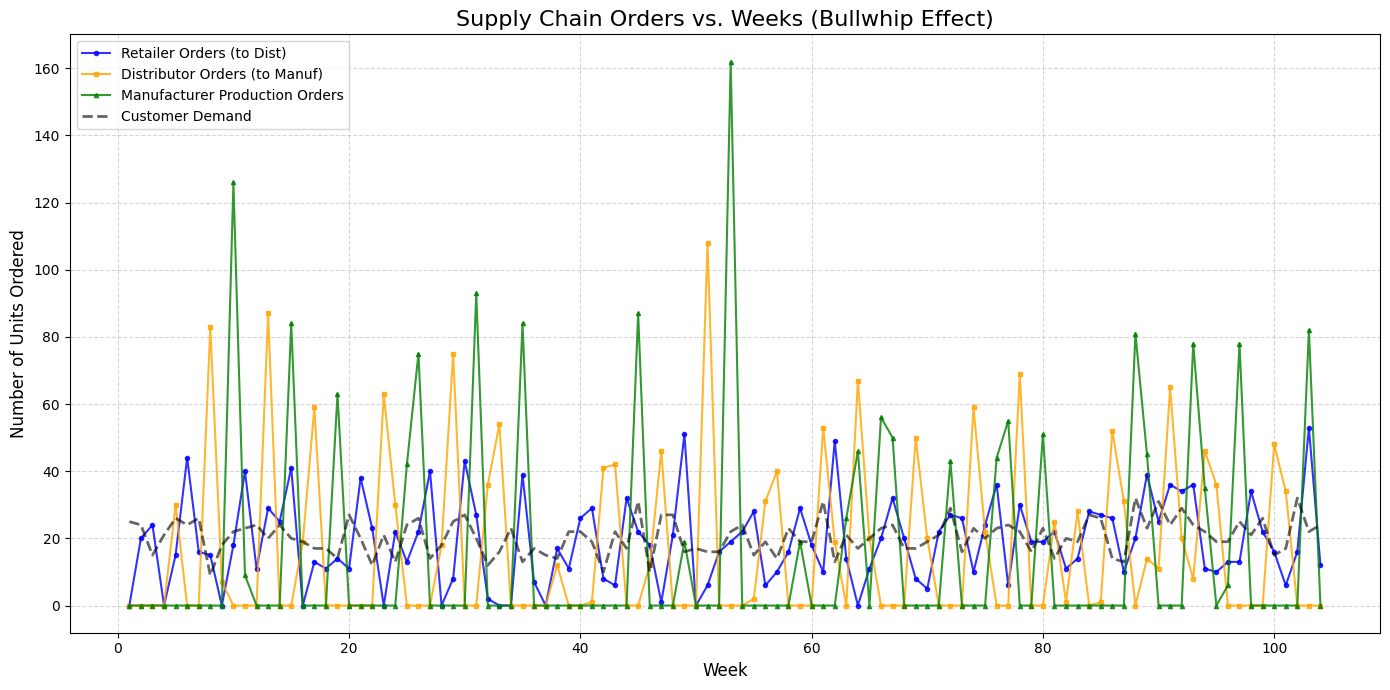

In [14]:
# ==========================================
# GRAPH 1: NUMBER OF ORDERS VS WEEKS
# ==========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Retailer places orders to Distributor
plt.plot(retailer_df["WEEK"], retailer_df[COLS['retailer']['order']],
         label="Retailer Orders (to Dist)", color='blue', marker='o', markersize=3, linewidth=1.5, alpha=0.8)

# Distributor places orders to Manufacturer
plt.plot(distributor_df["WEEK"], distributor_df[COLS['distributor']['order']],
         label="Distributor Orders (to Manuf)", color='orange', marker='s', markersize=3, linewidth=1.5, alpha=0.8)

# Manufacturer places orders for Production
plt.plot(manufacturer_df["WEEK"], manufacturer_df[COLS['manufacturer']['order']],
         label="Manufacturer Production Orders", color='green', marker='^', markersize=3, linewidth=1.5, alpha=0.8)

# Customer Demand (Reference)
plt.plot(retailer_df["WEEK"], retailer_df[COLS['retailer']['demand']],
         label="Customer Demand", color='black', linestyle='--', linewidth=2, alpha=0.6)

plt.title("Supply Chain Orders vs. Weeks (Bullwhip Effect)", fontsize=16)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Number of Units Ordered", fontsize=12)
plt.legend(fontsize=10, loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and Show
plt.savefig("graph_orders_vs_weeks.png")
plt.show()

# **10. CASH POSITION VS WEEKS**

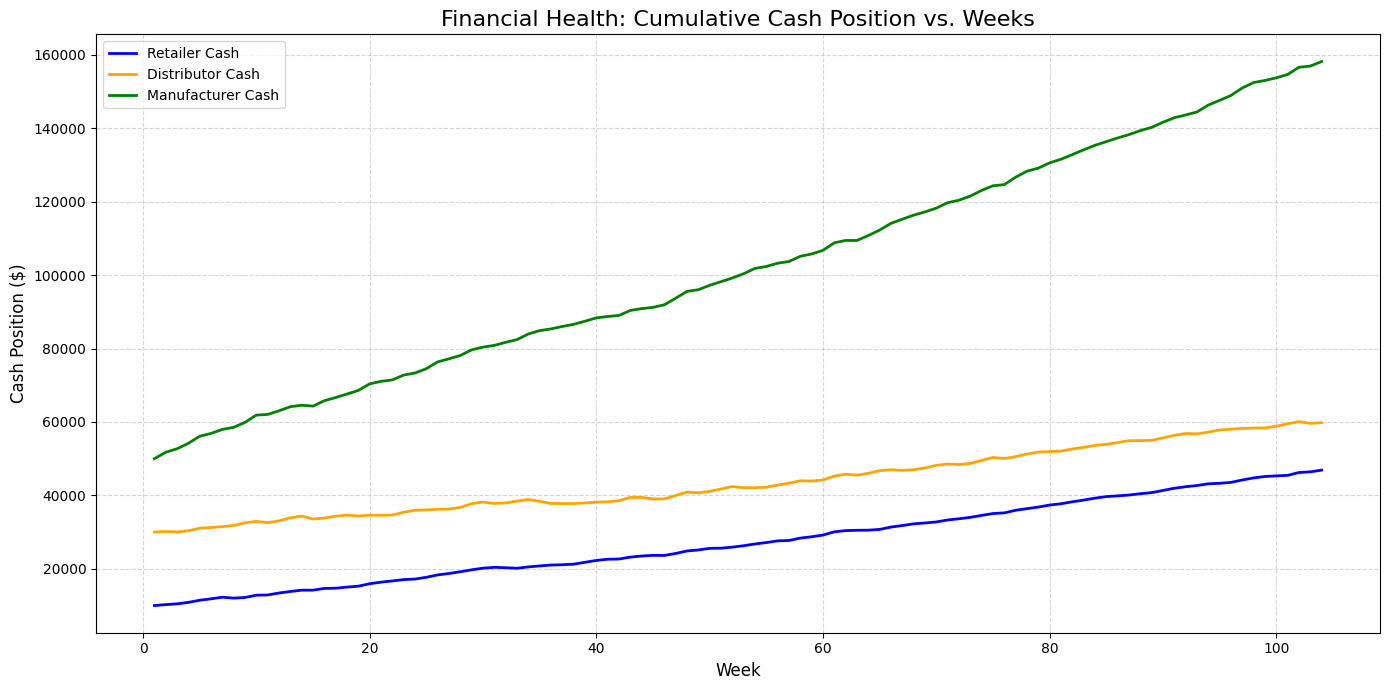

In [15]:
# ==========================================
# GRAPH 2: CASH POSITION VS WEEKS
# ==========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Plot Cash Positions
plt.plot(retailer_df["WEEK"], retailer_df["CASH POSITION"],
         label="Retailer Cash", color='blue', linewidth=2)

plt.plot(distributor_df["WEEK"], distributor_df["CASH POSITION"],
         label="Distributor Cash", color='orange', linewidth=2)

plt.plot(manufacturer_df["WEEK"], manufacturer_df["CASH POSITION"],
         label="Manufacturer Cash", color='green', linewidth=2)

plt.title("Financial Health: Cumulative Cash Position vs. Weeks", fontsize=16)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Cash Position ($)", fontsize=12)
plt.legend(fontsize=10, loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and Show
plt.savefig("graph_cash_position.png")
plt.show()

# **11. INVENTORY LEVELS VS WEEKS**

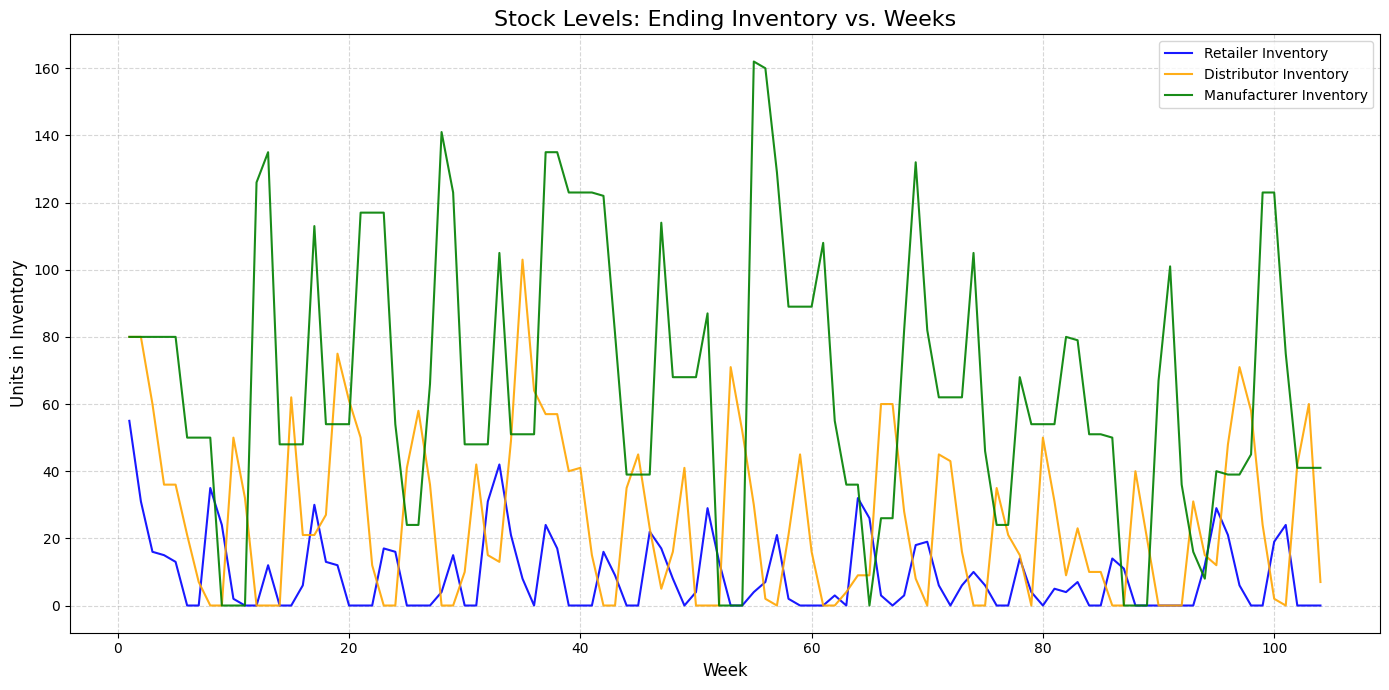

In [16]:
# ==========================================
# GRAPH 3: INVENTORY LEVELS VS WEEKS
# ==========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Plot Inventory Levels
plt.plot(retailer_df["WEEK"], retailer_df["ENDING INVENTORY"],
         label="Retailer Inventory", color='blue', linewidth=1.5, alpha=0.9)

plt.plot(distributor_df["WEEK"], distributor_df["ENDING INVENTORY"],
         label="Distributor Inventory", color='orange', linewidth=1.5, alpha=0.9)

plt.plot(manufacturer_df["WEEK"], manufacturer_df["ENDING INVENTORY"],
         label="Manufacturer Inventory", color='green', linewidth=1.5, alpha=0.9)

plt.title("Stock Levels: Ending Inventory vs. Weeks", fontsize=16)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Units in Inventory", fontsize=12)
plt.legend(fontsize=10, loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and Show
plt.savefig("graph_inventory_levels.png")
plt.show()